In [46]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [47]:
df=pd.read_csv("/Users/anshrathore/Desktop/Customer Churn Prediction Project/data/processed/churn_data_cleaned.csv")

In [48]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,-1.277445,0,1,-1.160323,-0.994194,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,0.066327,1,0,-0.259629,-0.173740,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,-1.236724,1,1,-0.362660,-0.959649,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,0.514251,0,0,-0.746535,-0.195248,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,-1.236724,1,1,0.197365,-0.940457,1,...,0,0,0,0,0,0,0,0,1,0


In [49]:
df.isnull().sum()[df.isnull().sum() > 0]

TotalCharges    11
dtype: int64

In [50]:
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
) ## ADDITIONAL CHANGES TO HANDLE MISSING VALUES IN TOTALCHARGES COLUMN

In [51]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [53]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [54]:
y_pred = lr.predict(X_test)

In [55]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



In [68]:
from sklearn.metrics import accuracy_score

y_pred_lr = lr.predict(X_test)

accuracy_lr = accuracy_score(
    y_test,
    y_pred_lr
)

print("Logistic Regression Accuracy:", accuracy_lr)

Logistic Regression Accuracy: 0.8048261178140526


In [56]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [57]:
y_pred_rf = rf.predict(X_test)

In [58]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.49      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.78      1409



In [59]:
from sklearn.metrics import accuracy_score

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.7842441447835344


In [60]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

print(cm)

[[922 113]
 [191 183]]


In [61]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [62]:
y_pred_xgb = xgb.predict(X_test)

In [63]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [64]:
from sklearn.metrics import accuracy_score

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)

print("XGBoost Accuracy:", accuracy_xgb)

XGBoost Accuracy: 0.8019872249822569


In [65]:
from sklearn.metrics import roc_auc_score

y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob_xgb)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8454287116691209


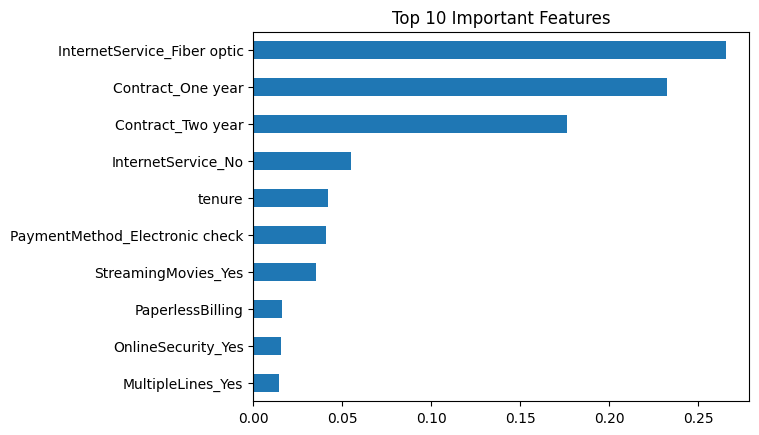

In [66]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    xgb.feature_importances_,
    index=X.columns
)

importance.nlargest(10).sort_values().plot(kind='barh')

plt.title("Top 10 Important Features")
plt.show()

In [69]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_rf
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.804826
1,Random Forest,0.784244


In [70]:
## FEATURE IMPORTANCE
import pandas as pd

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_[0]
})

coef_df.sort_values(
    by="Coefficient",
    ascending=False
).head(10)

,Feature,Coefficient
11,InternetService_Fiber optic,1.201208
8,TotalCharges,0.513881
24,StreamingMovies_Yes,0.384310
22,StreamingTV_Yes,0.383553
28,PaymentMethod_Electronic check,0.379821
6,PaperlessBilling,0.370548
10,MultipleLines_Yes,0.367336
1,SeniorCitizen,0.145206
29,PaymentMethod_Mailed check,0.068550
18,DeviceProtection_Yes,0.038976


In [71]:
coef_df.sort_values(
    by="Coefficient"
).head(10)

,Feature,Coefficient
26,Contract_Two year,-1.328676
4,tenure,-1.242104
25,Contract_One year,-0.685947
5,PhoneService,-0.496541
7,MonthlyCharges,-0.490583
14,OnlineSecurity_Yes,-0.345823
20,TechSupport_Yes,-0.295993
9,MultipleLines_No phone service,-0.263083
3,Dependents,-0.225872
17,DeviceProtection_No internet service,-0.175483


In [72]:
import joblib

joblib.dump(
    lr,
    "../models/churn_model.pkl"
)

FileNotFoundError: [Errno 2] No such file or directory: '../models/churn_model.pkl'

In [73]:
import os

os.makedirs("../models", exist_ok=True)

import joblib

joblib.dump(
    lr,
    "../models/churn_model.pkl"
)

['../models/churn_model.pkl']